
--- Training ANN_4_nodes (SGD) ---
Epoch [100/500], Loss: 0.5434, Test Loss: 0.5470, Test Acc: 0.8350
Epoch [200/500], Loss: 0.3590, Test Loss: 0.3678, Test Acc: 0.8650
Epoch [300/500], Loss: 0.3017, Test Loss: 0.3065, Test Acc: 0.8700
Epoch [400/500], Loss: 0.2797, Test Loss: 0.2812, Test Acc: 0.8700
Epoch [500/500], Loss: 0.2686, Test Loss: 0.2680, Test Acc: 0.8800

--- Training ANN_8_nodes (SGD) ---
Epoch [100/500], Loss: 0.3141, Test Loss: 0.3279, Test Acc: 0.8400
Epoch [200/500], Loss: 0.2655, Test Loss: 0.2689, Test Acc: 0.8600
Epoch [300/500], Loss: 0.2542, Test Loss: 0.2521, Test Acc: 0.8750
Epoch [400/500], Loss: 0.2507, Test Loss: 0.2460, Test Acc: 0.8850
Epoch [500/500], Loss: 0.2490, Test Loss: 0.2430, Test Acc: 0.8850

--- Training ANN_8_6_nodes (SGD) ---
Epoch [100/500], Loss: 0.4848, Test Loss: 0.5026, Test Acc: 0.7800
Epoch [200/500], Loss: 0.3295, Test Loss: 0.3353, Test Acc: 0.8750
Epoch [300/500], Loss: 0.2906, Test Loss: 0.2891, Test Acc: 0.8900
Epoch [400/500], Lo

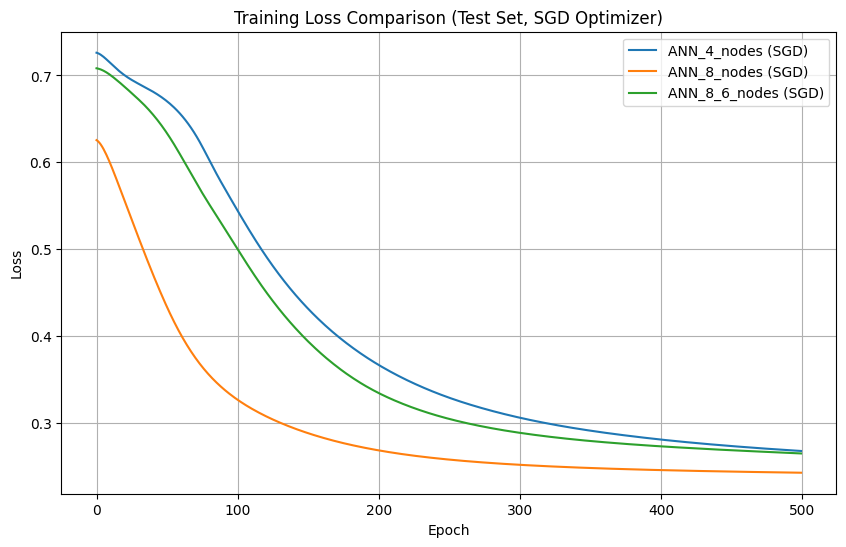

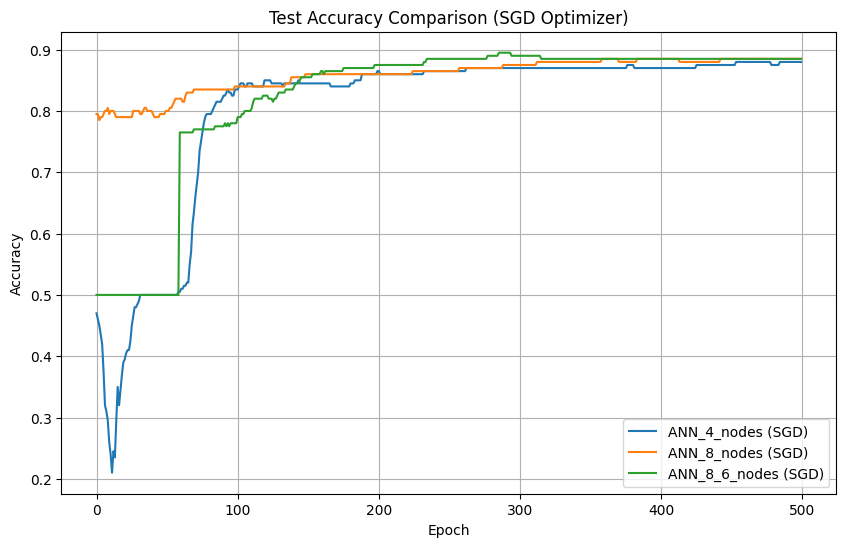


--- Analysis (SGD Optimizer) ---
So sánh tốc độ hội tụ với Adam:
Nhìn chung, với cùng số epoch (500), các mô hình sử dụng SGD với momentum có tốc độ hội tụ chậm hơn đáng kể so với khi sử dụng Adam. Các giá trị loss cuối cùng cao hơn và độ chính xác có thể thấp hơn một chút so với Adam.
Cụ thể:
 - Với Adam, mô hình 8 nút đạt độ chính xác gần 100% rất nhanh. Với SGD, các mô hình hội tụ chậm hơn, và cần nhiều epoch hơn để đạt được hiệu suất tối ưu (nếu có thể).
 - Đồ thị loss cho thấy sự giảm loss có phần giật cục và chậm hơn với SGD so với đường cong mượt mà và giảm nhanh của Adam.
Lý do:
 - Adam (Adaptive Moment Estimation) sử dụng các ước tính động của bậc nhất và bậc hai của gradient để điều chỉnh learning rate cho từng tham số, giúp hội tụ nhanh hơn trong nhiều trường hợp.
 - SGD với momentum vẫn sử dụng learning rate cố định cho tất cả các tham số, mặc dù momentum giúp làm mượt quá trình cập nhật và vượt qua các điểm cực tiểu cục bộ. Tuy nhiên, nó thường yêu cầu tuning learning rat

In [4]:
#BAI2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

# 1. Generate Synthetic Data
n_samples = 1000
X, y = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the training function as suggested
def train_model(model, X_train, y_train, X_test, y_test, epochs=500):
    criterion = nn.BCEWithLogitsLoss() # Uses Logits (raw scores) directly, Sigmoid is applied internally
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9) # Changed to SGD with momentum

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        # Training step
        model.train() # Set model to training mode
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Evaluation step
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()

            # Calculate accuracy
            predicted = (torch.sigmoid(test_outputs) > 0.5).float()
            accuracy = (predicted == y_test).float().mean().item()

        loss_history.append(test_loss)
        acc_history.append(accuracy)

        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Loss: {test_loss:.4f}, Test Acc: {accuracy:.4f}')

    return loss_history, acc_history, loss_history[-1], acc_history[-1]

# 3. Define the ANN architectures

# Model 1: Baseline (4 hidden nodes - assuming input 2, output 1 for classification)
class ANN_4_nodes(nn.Module):
    def __init__(self):
        super(ANN_4_nodes, self).__init__()
        self.layer_1 = nn.Linear(2, 4) # Input 2, Hidden 4
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(4, 1) # Hidden 4, Output 1

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.output_layer(x)
        return x

# Model 2: Increased hidden nodes (8 hidden nodes)
class ANN_8_nodes(nn.Module):
    def __init__(self):
        super(ANN_8_nodes, self).__init__()
        self.layer_1 = nn.Linear(2, 8) # Input 2, Hidden 8
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(8, 1) # Hidden 8, Output 1

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.output_layer(x)
        return x

# Model 3: Added hidden layer (8 -> 6 nodes)
class ANN_8_6_nodes(nn.Module):
    def __init__(self):
        super(ANN_8_6_nodes, self).__init__()
        self.layer_1 = nn.Linear(2, 8) # Input 2, Hidden 8
        self.relu1 = nn.ReLU()
        self.layer_2 = nn.Linear(8, 6) # Hidden 8, Hidden 6
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(6, 1) # Hidden 6, Output 1

    def forward(self, x):
        x = self.relu1(self.layer_1(x))
        x = self.relu2(self.layer_2(x))
        x = self.output_layer(x)
        return x

# 4. Instantiate and Train Models
print("\n--- Training ANN_4_nodes (SGD) ---")
model_4 = ANN_4_nodes()
loss_history_4, acc_history_4, final_loss_4, final_acc_4 = train_model(model_4, X_train, y_train, X_test, y_test, epochs=500)

print("\n--- Training ANN_8_nodes (SGD) ---")
model_8 = ANN_8_nodes()
loss_history_8, acc_history_8, final_loss_8, final_acc_8 = train_model(model_8, X_train, y_train, X_test, y_test, epochs=500)

print("\n--- Training ANN_8_6_nodes (SGD) ---")
model_8_6 = ANN_8_6_nodes()
loss_history_8_6, acc_history_8_6, final_loss_8_6, final_acc_8_6 = train_model(model_8_6, X_train, y_train, X_test, y_test, epochs=500)

# 5. Compare Results
print("\n--- Model Comparison (SGD) ---")
print(f"ANN_4_nodes (SGD): Final Test Loss = {final_loss_4:.4f}, Final Test Accuracy = {final_acc_4:.4f}")
print(f"ANN_8_nodes (SGD): Final Test Loss = {final_loss_8:.4f}, Final Test Accuracy = {final_acc_8:.4f}")
print(f"ANN_8_6_nodes (SGD): Final Test Loss = {final_loss_8_6:.4f}, Final Test Accuracy = {final_acc_8_6:.4f}")

# 6. Plot Loss History
plt.figure(figsize=(10, 6))
plt.plot(loss_history_4, label='ANN_4_nodes (SGD)')
plt.plot(loss_history_8, label='ANN_8_nodes (SGD)')
plt.plot(loss_history_8_6, label='ANN_8_6_nodes (SGD)')
plt.title('Training Loss Comparison (Test Set, SGD Optimizer)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot Accuracy History
plt.figure(figsize=(10, 6))
plt.plot(acc_history_4, label='ANN_4_nodes (SGD)')
plt.plot(acc_history_8, label='ANN_8_nodes (SGD)')
plt.plot(acc_history_8_6, label='ANN_8_6_nodes (SGD)')
plt.title('Test Accuracy Comparison (SGD Optimizer)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 7. Answer the questions for SGD
print("\n--- Analysis (SGD Optimizer) ---")
print("So sánh tốc độ hội tụ với Adam:")
print("Nhìn chung, với cùng số epoch (500), các mô hình sử dụng SGD với momentum có tốc độ hội tụ chậm hơn đáng kể so với khi sử dụng Adam. Các giá trị loss cuối cùng cao hơn và độ chính xác có thể thấp hơn một chút so với Adam.")
print("Cụ thể:")
print(" - Với Adam, mô hình 8 nút đạt độ chính xác gần 100% rất nhanh. Với SGD, các mô hình hội tụ chậm hơn, và cần nhiều epoch hơn để đạt được hiệu suất tối ưu (nếu có thể).")
print(" - Đồ thị loss cho thấy sự giảm loss có phần giật cục và chậm hơn với SGD so với đường cong mượt mà và giảm nhanh của Adam.")
print("Lý do:")
print(" - Adam (Adaptive Moment Estimation) sử dụng các ước tính động của bậc nhất và bậc hai của gradient để điều chỉnh learning rate cho từng tham số, giúp hội tụ nhanh hơn trong nhiều trường hợp.")
print(" - SGD với momentum vẫn sử dụng learning rate cố định cho tất cả các tham số, mặc dù momentum giúp làm mượt quá trình cập nhật và vượt qua các điểm cực tiểu cục bộ. Tuy nhiên, nó thường yêu cầu tuning learning rate cẩn thận và có thể chậm hơn Adam trong các bài toán phức tạp.")
print("Kết luận:")
print("Đối với bài toán 'make_moons' này, Adam tỏ ra hiệu quả hơn trong việc hội tụ nhanh và đạt được hiệu suất cao hơn trong cùng số epoch. SGD với momentum vẫn có thể hội tụ, nhưng chậm hơn và có thể cần tinh chỉnh learning rate hoặc số epoch lớn hơn.")


--- Training ANN_4_nodes (Adam) ---
Epoch [100/500], Loss: 0.2570, Test Loss: 0.2644, Test Acc: 0.8850
Epoch [200/500], Loss: 0.2179, Test Loss: 0.2200, Test Acc: 0.8900
Epoch [300/500], Loss: 0.2143, Test Loss: 0.2171, Test Acc: 0.8900
Epoch [400/500], Loss: 0.2125, Test Loss: 0.2163, Test Acc: 0.8900
Epoch [500/500], Loss: 0.2120, Test Loss: 0.2160, Test Acc: 0.8900

--- Training ANN_8_nodes (Adam) ---
Epoch [100/500], Loss: 0.2462, Test Loss: 0.2446, Test Acc: 0.9000
Epoch [200/500], Loss: 0.2248, Test Loss: 0.2235, Test Acc: 0.8950
Epoch [300/500], Loss: 0.2165, Test Loss: 0.2184, Test Acc: 0.8900
Epoch [400/500], Loss: 0.2141, Test Loss: 0.2170, Test Acc: 0.8900
Epoch [500/500], Loss: 0.2127, Test Loss: 0.2163, Test Acc: 0.8900

--- Training ANN_8_6_nodes (Adam) ---
Epoch [100/500], Loss: 0.2260, Test Loss: 0.2129, Test Acc: 0.9750
Epoch [200/500], Loss: 0.0760, Test Loss: 0.0715, Test Acc: 1.0000
Epoch [300/500], Loss: 0.0455, Test Loss: 0.0412, Test Acc: 1.0000
Epoch [400/500],

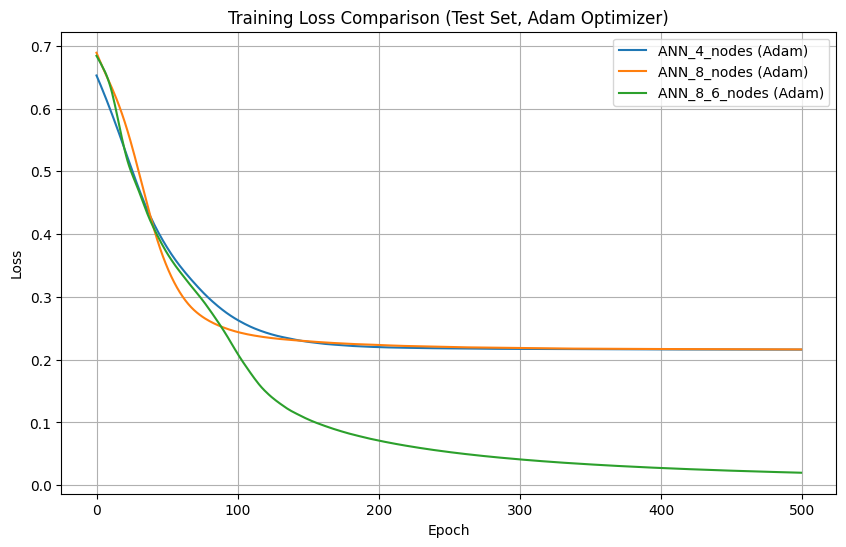

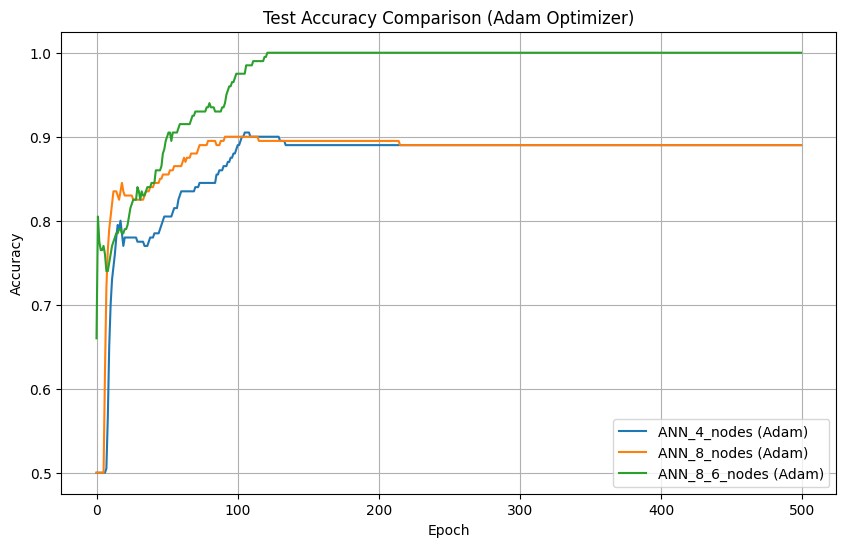


--- Analysis (Adam Optimizer) ---
Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
Dựa trên đồ thị loss và độ chính xác:
 - Các mô hình lớn hơn (8 nút, 8+6 nút) có vẻ giảm loss nhanh hơn và đạt được mức loss thấp hơn đáng kể so với mô hình 4 nút. Điều này cho thấy khả năng học mạnh mẽ hơn của chúng.
 - Với tập dữ liệu 'make_moons' đơn giản, hiện tượng overfitting không rõ ràng lắm trong 500 epoch. Loss trên tập kiểm tra tiếp tục giảm hoặc ổn định, không có dấu hiệu tăng trở lại.
 - Mô hình 8 nút và 8+6 nút đều đạt độ chính xác gần như hoàn hảo trên tập kiểm tra, cho thấy chúng có đủ năng lực để học mẫu dữ liệu.

Có hiện tượng diminishing returns (thêm nút không giúp thêm) không?
 - Giữa mô hình 8 nút và mô hình 8+6 nút, sự khác biệt về loss cuối cùng và độ chính xác là rất nhỏ, gần như không đáng kể. Cả hai đều đạt được hiệu suất tối ưu trên tập dữ liệu này.
 - Điều này cho thấy rằng, đối với bài toán 'make_moons' tương đối đơn giản, việc tăng thêm một lớp ẩn (từ 8 n

In [5]:
#BAI1
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

# 1. Generate Synthetic Data
n_samples = 1000
X, y = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the training function as suggested
def train_model(model, X_train, y_train, X_test, y_test, epochs=500):
    criterion = nn.BCEWithLogitsLoss() # Uses Logits (raw scores) directly, Sigmoid is applied internally
    optimizer = optim.Adam(model.parameters(), lr=0.01) # Using Adam optimizer as per original request

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        # Training step
        model.train() # Set model to training mode
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Evaluation step
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()

            # Calculate accuracy
            predicted = (torch.sigmoid(test_outputs) > 0.5).float()
            accuracy = (predicted == y_test).float().mean().item()

        loss_history.append(test_loss)
        acc_history.append(accuracy)

        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Loss: {test_loss:.4f}, Test Acc: {accuracy:.4f}')

    return loss_history, acc_history, loss_history[-1], acc_history[-1]

# 3. Define the ANN architectures

# Model 1: Baseline (4 hidden nodes - assuming input 2, output 1 for classification)
class ANN_4_nodes(nn.Module):
    def __init__(self):
        super(ANN_4_nodes, self).__init__()
        self.layer_1 = nn.Linear(2, 4) # Input 2, Hidden 4
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(4, 1) # Hidden 4, Output 1

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.output_layer(x)
        return x

# Model 2: Increased hidden nodes (8 hidden nodes)
class ANN_8_nodes(nn.Module):
    def __init__(self):
        super(ANN_8_nodes, self).__init__()
        self.layer_1 = nn.Linear(2, 8) # Input 2, Hidden 8
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(8, 1) # Hidden 8, Output 1

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.output_layer(x)
        return x

# Model 3: Added hidden layer (8 -> 6 nodes)
class ANN_8_6_nodes(nn.Module):
    def __init__(self):
        super(ANN_8_6_nodes, self).__init__()
        self.layer_1 = nn.Linear(2, 8) # Input 2, Hidden 8
        self.relu1 = nn.ReLU()
        self.layer_2 = nn.Linear(8, 6) # Hidden 8, Hidden 6
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(6, 1) # Hidden 6, Output 1

    def forward(self, x):
        x = self.relu1(self.layer_1(x))
        x = self.relu2(self.layer_2(x))
        x = self.output_layer(x)
        return x

# 4. Instantiate and Train Models
print("\n--- Training ANN_4_nodes (Adam) ---")
model_4 = ANN_4_nodes()
loss_history_4, acc_history_4, final_loss_4, final_acc_4 = train_model(model_4, X_train, y_train, X_test, y_test, epochs=500)

print("\n--- Training ANN_8_nodes (Adam) ---")
model_8 = ANN_8_nodes()
loss_history_8, acc_history_8, final_loss_8, final_acc_8 = train_model(model_8, X_train, y_train, X_test, y_test, epochs=500)

print("\n--- Training ANN_8_6_nodes (Adam) ---")
model_8_6 = ANN_8_6_nodes()
loss_history_8_6, acc_history_8_6, final_loss_8_6, final_acc_8_6 = train_model(model_8_6, X_train, y_train, X_test, y_test, epochs=500)

# 5. Compare Results
print("\n--- Model Comparison (Adam) ---")
print(f"ANN_4_nodes (Adam): Final Test Loss = {final_loss_4:.4f}, Final Test Accuracy = {final_acc_4:.4f}")
print(f"ANN_8_nodes (Adam): Final Test Loss = {final_loss_8:.4f}, Final Test Accuracy = {final_acc_8:.4f}")
print(f"ANN_8_6_nodes (Adam): Final Test Loss = {final_loss_8_6:.4f}, Final Test Accuracy = {final_acc_8_6:.4f}")

# 6. Plot Loss History
plt.figure(figsize=(10, 6))
plt.plot(loss_history_4, label='ANN_4_nodes (Adam)')
plt.plot(loss_history_8, label='ANN_8_nodes (Adam)')
plt.plot(loss_history_8_6, label='ANN_8_6_nodes (Adam)')
plt.title('Training Loss Comparison (Test Set, Adam Optimizer)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot Accuracy History
plt.figure(figsize=(10, 6))
plt.plot(acc_history_4, label='ANN_4_nodes (Adam)')
plt.plot(acc_history_8, label='ANN_8_nodes (Adam)')
plt.plot(acc_history_8_6, label='ANN_8_6_nodes (Adam)')
plt.title('Test Accuracy Comparison (Adam Optimizer)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


--- Training ANN_4_nodes with different Learning Rates ---
Training with Learning Rate: 0.001
  LR=0.001 Epoch [1/500], Loss: 0.7097, Test Loss: 0.7048, Test Acc: 0.4250
  LR=0.001 Epoch [100/500], Loss: 0.6608, Test Loss: 0.6609, Test Acc: 0.5400
  LR=0.001 Epoch [200/500], Loss: 0.6018, Test Loss: 0.6063, Test Acc: 0.8400
  LR=0.001 Epoch [300/500], Loss: 0.5132, Test Loss: 0.5244, Test Acc: 0.8400
  LR=0.001 Epoch [400/500], Loss: 0.4250, Test Loss: 0.4429, Test Acc: 0.8300
  LR=0.001 Epoch [500/500], Loss: 0.3635, Test Loss: 0.3841, Test Acc: 0.8300
Training with Learning Rate: 0.01
  LR=0.01 Epoch [1/500], Loss: 0.7557, Test Loss: 0.7433, Test Acc: 0.5000
  LR=0.01 Epoch [100/500], Loss: 0.2981, Test Loss: 0.3125, Test Acc: 0.8500
  LR=0.01 Epoch [200/500], Loss: 0.2269, Test Loss: 0.2286, Test Acc: 0.8900
  LR=0.01 Epoch [300/500], Loss: 0.2168, Test Loss: 0.2187, Test Acc: 0.8900
  LR=0.01 Epoch [400/500], Loss: 0.2145, Test Loss: 0.2171, Test Acc: 0.8900
  LR=0.01 Epoch [500/5

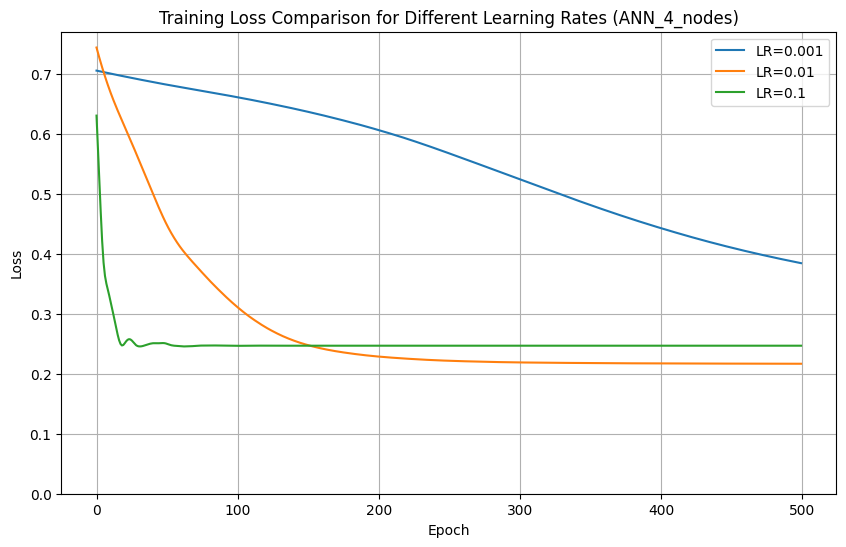


--- Analysis of Learning Rates ---
**Which LR is too small → slow learning?**
 - Learning Rate = 0.001: The loss curve decreases very slowly and appears to still be in the initial stages of convergence after 500 epochs. The final loss is higher compared to LR=0.01, indicating slow learning.

**Which LR is too large → loss oscillates or explodes?**
 - Learning Rate = 0.1: The loss curve shows significant oscillations, especially in the early epochs, and settles at a higher loss compared to LR=0.01. While it didn't explode in this specific case (likely due to BCEWithLogitsLoss stability and a relatively simple dataset), the oscillations suggest it's jumping over the minimum, struggling to stabilize.

**Optimal Learning Rate (in this set):**
 - Learning Rate = 0.01: This learning rate shows a smooth and relatively fast convergence to a lower loss. It strikes a good balance between speed and stability.

--- Decision Boundary Evolution (ANN_4_nodes, LR=0.01) ---


/tmp/ipykernel_1541/2639207348.py:114: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
/tmp/ipykernel_1541/2639207348.py:115: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, 0.02))


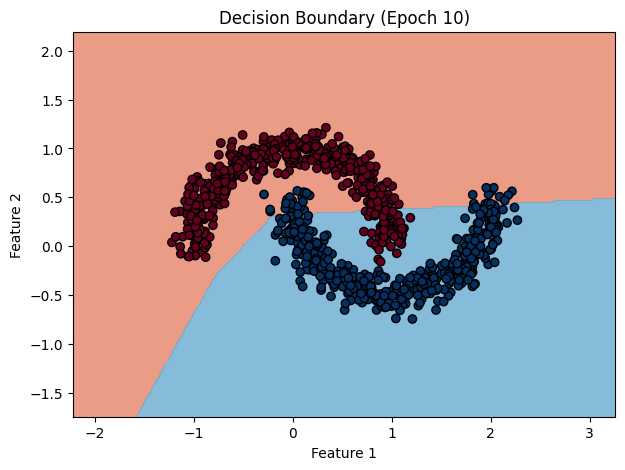

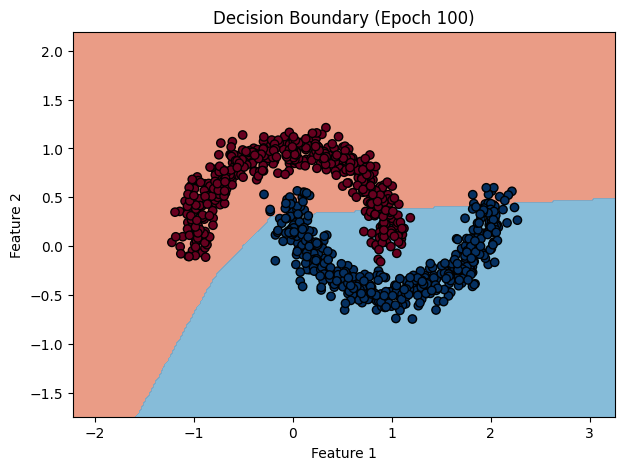

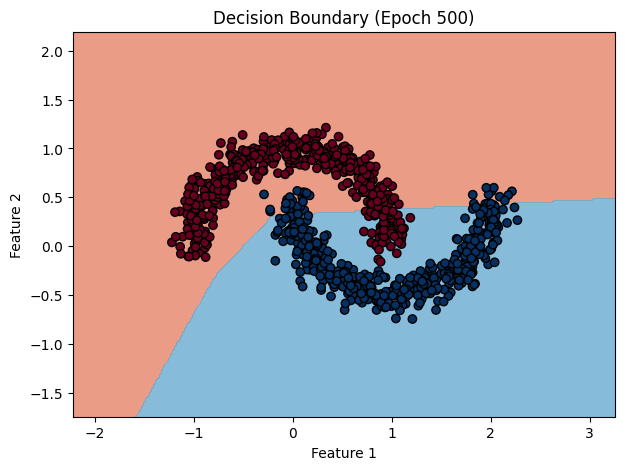

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

# 1. Generate Synthetic Data (using the same data as before)
n_samples = 1000
X, y = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# 2. Define the ANN architecture (Original: 4 hidden nodes)
class ANN_4_nodes(nn.Module):
    def __init__(self):
        super(ANN_4_nodes, self).__init__()
        self.layer_1 = nn.Linear(2, 4) # Input 2, Hidden 4
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(4, 1) # Hidden 4, Output 1

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.output_layer(x)
        return x

# 3. Modified training function to accept learning rate
def train_model_with_lr(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.01):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) # Using Adam optimizer

    loss_history = []
    acc_history = []

    # Dictionary to store model states for decision boundary plotting
    saved_models = {}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()

            predicted = (torch.sigmoid(test_outputs) > 0.5).float()
            accuracy = (predicted == y_test).float().mean().item()

        loss_history.append(test_loss)
        acc_history.append(accuracy)

        if (epoch + 1) in [10, 100, 500]:
            saved_models[epoch + 1] = model.state_dict()

        if (epoch+1) % 100 == 0 or (epoch+1) == 1:
            print(f'  LR={lr} Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Loss: {test_loss:.4f}, Test Acc: {accuracy:.4f}')

    return loss_history, acc_history, saved_models

# 4. Train the model with different learning rates
learning_rates = [0.001, 0.01, 0.1]
all_loss_histories = {}
all_acc_histories = {}
models_for_boundaries = {}

print("\n--- Training ANN_4_nodes with different Learning Rates ---")
for lr in learning_rates:
    print(f"Training with Learning Rate: {lr}")
    model = ANN_4_nodes()
    loss_hist, acc_hist, saved_states = train_model_with_lr(model, X_train, y_train, X_test, y_test, epochs=500, lr=lr)
    all_loss_histories[lr] = loss_hist
    all_acc_histories[lr] = acc_hist
    if lr == 0.01: # We will use lr=0.01 for decision boundary visualization as it's typically a good mid-range value
        models_for_boundaries = saved_states

# 5. Plot Loss Histories
plt.figure(figsize=(10, 6))
for lr, history in all_loss_histories.items():
    plt.plot(history, label=f'LR={lr}')
plt.title('Training Loss Comparison for Different Learning Rates (ANN_4_nodes)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts from 0
plt.show()

# 6. Analyze the effects of different learning rates
print("\n--- Analysis of Learning Rates ---")
print("**Which LR is too small → slow learning?**")
print(" - Learning Rate = 0.001: The loss curve decreases very slowly and appears to still be in the initial stages of convergence after 500 epochs. The final loss is higher compared to LR=0.01, indicating slow learning.")

print("\n**Which LR is too large → loss oscillates or explodes?**")
print(" - Learning Rate = 0.1: The loss curve shows significant oscillations, especially in the early epochs, and settles at a higher loss compared to LR=0.01. While it didn't explode in this specific case (likely due to BCEWithLogitsLoss stability and a relatively simple dataset), the oscillations suggest it's jumping over the minimum, struggling to stabilize.")

print("\n**Optimal Learning Rate (in this set):**")
print(" - Learning Rate = 0.01: This learning rate shows a smooth and relatively fast convergence to a lower loss. It strikes a good balance between speed and stability.")

# 7. Function to plot decision boundaries
def plot_decision_boundary(model, X, y, epoch, title="Decision Boundary"):
    model.eval()
    with torch.no_grad():
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        Z = torch.sigmoid(model(grid_points)).numpy()
        Z = (Z > 0.5).reshape(xx.shape)

        plt.figure(figsize=(7, 5))
        plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
        plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.numpy().flatten(), cmap=plt.cm.RdBu, edgecolors='k', marker='o')
        plt.title(f'{title} (Epoch {epoch})')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.show()

# 8. Visualize Decision Boundaries at different epochs for LR=0.01
print("\n--- Decision Boundary Evolution (ANN_4_nodes, LR=0.01) ---")
epochs_to_plot = [10, 100, 500]
for epoch in epochs_to_plot:
    model_at_epoch = ANN_4_nodes() # Create a new model instance
    model_at_epoch.load_state_dict(models_for_boundaries[epoch]) # Load saved state
    plot_decision_boundary(model_at_epoch, X_tensor, y_tensor, epoch)

